**Set Up**

In [4]:
!pip install -q numpy pandas scikit-learn gradio matplotlib torch tokenizers langchain openai

import re
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:

df = pd.read_csv("/content/Jadarat_data.csv")
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

arabic_diacritics = re.compile(r"\u0651|\u064E|\u064B|\u064F|\u064C|\u0650|\u064D|\u0652|\u0640")

def normalize_arabic(text: str) -> str:
    """
    \u062a\u0646\u0638\u064a\u0641 \u0627\u0644\u0646\u0635 \u0627\u0644\u0639\u0631\u0628\u064a: \u0625\u0632\u0627\u0644\u0629 \u0627\u0644\u062a\u0634\u0643\u064a\u0644\u060c \u062a\u0648\u062d\u064a\u062f \u0627\u0644\u0647\u0645\u0632\u0627\u062a (\u0623\u060c \u0625\u060c \u0622 -> \u0627)\u060c
    \u062a\u0648\u062d\u064a\u062f \u0627\u0644\u064a\u0627\u0621 \u0648\u0627\u0644\u0623\u0644\u0641 \u0627\u0644\u0645\u0642\u0635\u0648\u0631\u0629\u060c \u0648\u0625\u0632\u0627\u0644\u0629 \u0627\u0644\u0631\u0645\u0648\u0632 \u063a\u064a\u0631 \u0627\u0644\u0646\u0635\u064a\u0629.
    """
    text = str(text)
    text = re.sub(arabic_diacritics, "", text)
    text = re.sub(r"[\u0625\u0623\u0622\u0627]", "\u0627", text)
    text = re.sub("\u0649", "\u064a", text)
    text = re.sub("\u0624", "\u0648", text)
    text = re.sub("\u0626", "\u064a", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["job_text"] = (
    "\u0627\u0644\u0645\u0633\u0645\u0649: " + df.get("\u0627\u0644\u0645\u0633\u0645\u0649 \u0627\u0644\u0648\u0638\u064a\u0641\u064a", "").astype(str) + " | " +
    "\u0627\u0644\u0645\u062f\u064a\u0646\u0629: " + df.get("\u0627\u0644\u0645\u062f\u064a\u0646\u0629", "").astype(str) + " | " +
    "\u0627\u0644\u0648\u0635\u0641: " + df.get("\u0627\u0644\u0648\u0635\u0641 \u0627\u0644\u0648\u0638\u064a\u0641\u064a", "").astype(str)
)
df["job_text"] = df["job_text"].apply(normalize_arabic)

print("Dataset size:", df.shape)

Dataset size: (7041, 8)


In [6]:

vocab_size = 5000
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()


trainer = trainers.BpeTrainer(
    vocab_size=vocab_size,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)


tokenizer.train_from_iterator(df["job_text"].tolist(), trainer=trainer)

PAD_IDX = tokenizer.token_to_id("[PAD]")
BOS_IDX = tokenizer.token_to_id("[BOS]")
EOS_IDX = tokenizer.token_to_id("[EOS]")

class JobDataset(Dataset):
    """
    \u062a\u062c\u0647\u064a\u0632 \u0627\u0644\u0628\u064a\u0627\u0646\u0627\u062a \u0643\u0645\u062f\u062e\u0644\u0627\u062a (Inputs) \u0648\u0645\u062e\u0631\u062c\u0627\u062a (Targets) \u0644\u062a\u062f\u0631\u064a\u0628 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u062e\u0637\u0648\u0629 \u0628\u062e\u0637\u0648\u0629.
    """
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer.encode(text).ids

        encoded = [BOS_IDX] + encoded[:self.max_len-2] + [EOS_IDX]
        padding_length = self.max_len - len(encoded)
        encoded = encoded + [PAD_IDX] * padding_length


        x = torch.tensor(encoded[:-1], dtype=torch.long)
        y = torch.tensor(encoded[1:], dtype=torch.long)
        return x, y


train_texts, test_texts = train_test_split(df["job_text"].tolist(), test_size=0.1, random_state=42)
train_dataset = JobDataset(train_texts, tokenizer)
test_dataset = JobDataset(test_texts, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [7]:
class MultiHeadAttention(nn.Module):
    """\u0637\u0628\u0642\u0629 \u0627\u0644\u0627\u0646\u062a\u0628\u0627\u0647 \u0645\u062a\u0639\u062f\u062f \u0627\u0644\u0631\u0624\u0648\u0633 \u0644\u0645\u0639\u0631\u0641\u0629 \u0639\u0644\u0627\u0642\u0629 \u0627\u0644\u0643\u0644\u0645\u0627\u062a \u0628\u0628\u0639\u0636\u0647\u0627"""
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0
        self.depth = d_model // num_heads

        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        return x.view(batch_size, -1, self.num_heads, self.depth).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)

        if mask is not None:
            scores += (mask * -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.dense(output)

class TransformerBlock(nn.Module):

    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dff),
            nn.ReLU(),
            nn.Linear(dff, d_model)
        )
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        attn_output = self.mha(x, x, x, mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output))
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + self.dropout2(ffn_output))
        return out2

class JobRecommendationGPT(nn.Module):

    def __init__(self, vocab_size, d_model=256, num_layers=4, num_heads=8, dff=512, max_len=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Embedding(max_len, d_model)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, dff) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def create_look_ahead_mask(self, size):

        mask = torch.triu(torch.ones(size, size), diagonal=1).to(device)
        return mask

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len).unsqueeze(0).to(device)

        x = self.embedding(x) + self.pos_encoding(positions)
        mask = self.create_look_ahead_mask(seq_len)

        for block in self.blocks:
            x = block(x, mask)

        return self.fc_out(x)


model = JobRecommendationGPT(vocab_size=tokenizer.get_vocab_size()).to(device)

Epoch 1/2:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 1 | متوسط الخسارة: 6.7584


Epoch 2/2:   0%|          | 0/50 [00:00<?, ?it/s]


✅ انتهاء Epoch 2 | متوسط الخسارة: 5.0220


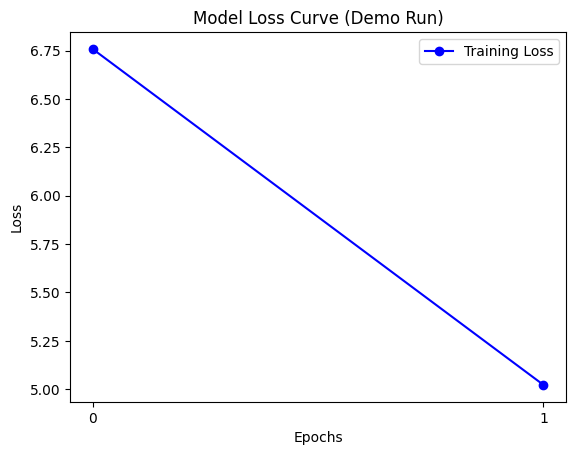

In [8]:
from tqdm.auto import tqdm


optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


epochs = 2
DEMO_MODE = True
MAX_BATCHES = 50


train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0


    total_steps = MAX_BATCHES if DEMO_MODE else len(train_loader)
    progress_bar = tqdm(enumerate(train_loader), total=total_steps, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, (x, y) in progress_bar:

        if DEMO_MODE and batch_idx >= MAX_BATCHES:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)


        loss = criterion(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        loss.backward()


        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()


        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = total_loss / total_steps
    train_losses.append(avg_loss)
    print(f"\n\u2705 \u0627\u0646\u062a\u0647\u0627\u0621 Epoch {epoch+1} | \u0645\u062a\u0648\u0633\u0637 \u0627\u0644\u062e\u0633\u0627\u0631\u0629: {avg_loss:.4f}")


    torch.save(model.state_dict(), 'best_model.pt')


plt.plot(train_losses, marker='o', color='blue', label='Training Loss')
plt.title('Model Loss Curve (Demo Run)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()
plt.show()

## Extended Full Training

In [9]:
# ---- Split training set further into train / validation ----
train_texts_full, val_texts = train_test_split(train_texts, test_size=0.1, random_state=42)

train_dataset_full = JobDataset(train_texts_full, tokenizer)
val_dataset = JobDataset(val_texts, tokenizer)

train_loader_full = DataLoader(train_dataset_full, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print(f"Full-train size : {len(train_dataset_full)}")
print(f"Validation size : {len(val_dataset)}")
print(f"Test size       : {len(test_dataset)}")

Full-train size : 5702
Validation size : 634
Test size       : 705


In [12]:
# ---- Extended training: 10 epochs, full data, with validation ----
from tqdm.auto import tqdm

EXTENDED_EPOCHS = 10

# Re-initialise model for a clean full run
model_full = JobRecommendationGPT(vocab_size=tokenizer.get_vocab_size()).to(device)

optimizer_full = torch.optim.AdamW(model_full.parameters(), lr=3e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=EXTENDED_EPOCHS)
criterion_full = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

full_train_losses = []
full_val_losses = []
best_val_loss = float('inf')

for epoch in range(EXTENDED_EPOCHS):
    # ---------- Training ----------
    model_full.train()
    running_loss = 0.0
    n_batches = 0

    progress = tqdm(train_loader_full, desc=f"Epoch {epoch+1}/{EXTENDED_EPOCHS} [train]")
    for x, y in progress:
        x, y = x.to(device), y.to(device)

        optimizer_full.zero_grad()
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_full.parameters(), max_norm=1.0)
        optimizer_full.step()

        running_loss += loss.item()
        n_batches += 1
        progress.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = running_loss / n_batches
    full_train_losses.append(avg_train_loss)

    # ---------- Validation ----------
    model_full.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            output = model_full(x)
            loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    full_val_losses.append(avg_val_loss)

    scheduler.step()

    # Save best checkpoint
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model_full.state_dict(), 'best_model_full.pt')

    current_lr = optimizer_full.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>2}/{EXTENDED_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"LR: {current_lr:.6f}")

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 1/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss: 5.0128 | Val Loss: 3.2277 | LR: 0.000293


Epoch 2/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  2/10 | Train Loss: 2.7229 | Val Loss: 2.2207 | LR: 0.000271


Epoch 3/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

...

Epoch  8/10 | Train Loss: 1.1803 | Val Loss: 1.4050 | LR: 0.000029


Epoch 9/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 1.1405 | Val Loss: 1.3978 | LR: 0.000007


Epoch 10/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.1232 | Val Loss: 1.3941 | LR: 0.000000

Best validation loss: 1.3941


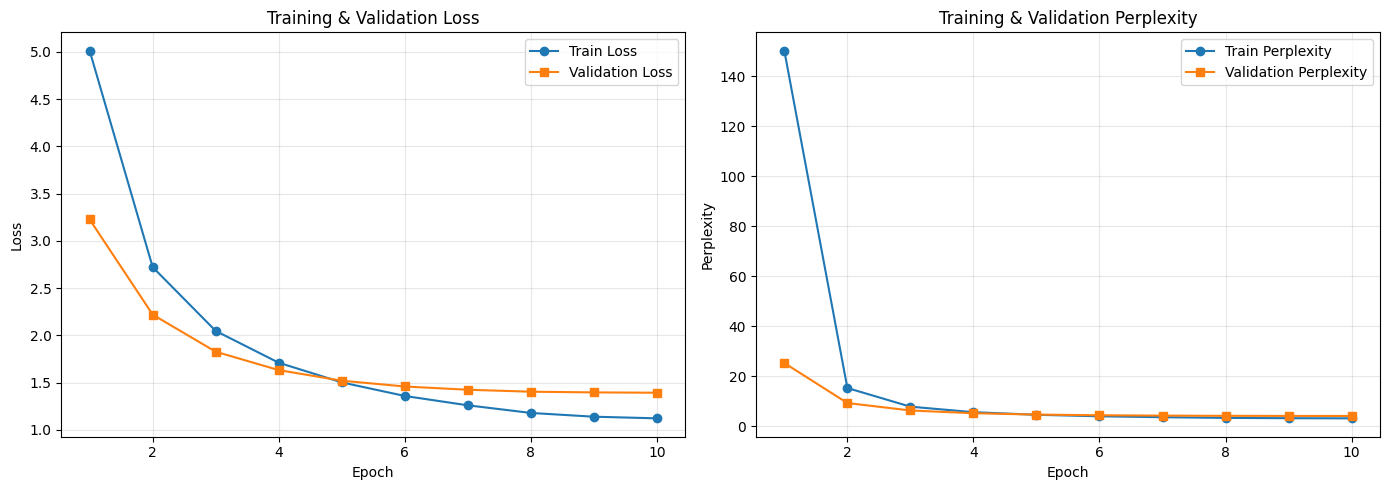

In [13]:
# ---- Plot training & validation loss curves ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: both curves
axes[0].plot(range(1, EXTENDED_EPOCHS + 1), full_train_losses, marker='o', label='Train Loss')
axes[0].plot(range(1, EXTENDED_EPOCHS + 1), full_val_losses, marker='s', label='Validation Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: perplexity
train_ppl = [math.exp(l) for l in full_train_losses]
val_ppl   = [math.exp(l) for l in full_val_losses]
axes[1].plot(range(1, EXTENDED_EPOCHS + 1), train_ppl, marker='o', label='Train Perplexity')
axes[1].plot(range(1, EXTENDED_EPOCHS + 1), val_ppl, marker='s', label='Validation Perplexity')
axes[1].set_title('Training & Validation Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
def generate_text(prompt, max_tokens=50, temperature=0.7):
    """\u062a\u0648\u0644\u064a\u062f \u0627\u0644\u0646\u0635 \u0643\u0644\u0645\u0629 \u0628\u0643\u0644\u0645\u0629 (Autoregressive)"""
    model_full.eval()
    prompt = normalize_arabic(prompt)
    input_ids = tokenizer.encode(prompt).ids
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    generated_ids = input_ids.copy()

    with torch.no_grad():
        for _ in range(max_tokens):
            # Truncate to max_len - 1 to stay within positional encoding range
            if len(generated_ids) >= model_full.max_len:
                break
            outputs = model_full(input_tensor)
            next_token_logits = outputs[0, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

            if next_token == EOS_IDX:
                break

            generated_ids.append(next_token)
            input_tensor = torch.tensor([generated_ids], dtype=torch.long).to(device)

    return tokenizer.decode(generated_ids)


# Load the best full-training checkpoint
model_full.load_state_dict(torch.load('best_model_full.pt', map_location=device))
model_full.eval()
print("Loaded best_model_full.pt")

Loaded best_model_full.pt


## Comprehensive Testing & Evaluation

In [15]:
# ---- 1. Test-set Loss & Perplexity ----
model_full.eval()
test_loss_total = 0.0
test_batches = 0

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Evaluating test set"):
        x, y = x.to(device), y.to(device)
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        test_loss_total += loss.item()
        test_batches += 1

avg_test_loss = test_loss_total / test_batches
test_perplexity = math.exp(avg_test_loss)

print(f"\n--- Test Results ---")
print(f"Test Loss      : {avg_test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.2f}")

Evaluating test set:   0%|          | 0/23 [00:00<?, ?it/s]


--- Test Results ---
Test Loss      : 1.4696
Test Perplexity: 4.35


In [16]:
# ---- 2. Top-k Token Prediction Accuracy ----
def compute_topk_accuracy(model, loader, ks=(1, 5, 10)):
    """Compute top-k accuracy over non-PAD tokens on a DataLoader."""
    model.eval()
    correct = {k: 0 for k in ks}
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)                       # (B, S, V)
            mask = (y != PAD_IDX)                    # ignore padding
            total += mask.sum().item()

            for k in ks:
                topk_preds = logits.topk(k, dim=-1).indices  # (B, S, k)
                matches = (topk_preds == y.unsqueeze(-1)).any(dim=-1)  # (B, S)
                correct[k] += (matches & mask).sum().item()

    return {k: correct[k] / total * 100 for k in ks}


topk_results = compute_topk_accuracy(model_full, test_loader, ks=(1, 5, 10))
print("\n--- Top-k Token Accuracy on Test Set ---")
for k, acc in topk_results.items():
    print(f"  Top-{k:>2}: {acc:.2f}%")


--- Top-k Token Accuracy on Test Set ---
  Top- 1: 75.70%
  Top- 5: 82.68%
  Top-10: 84.98%


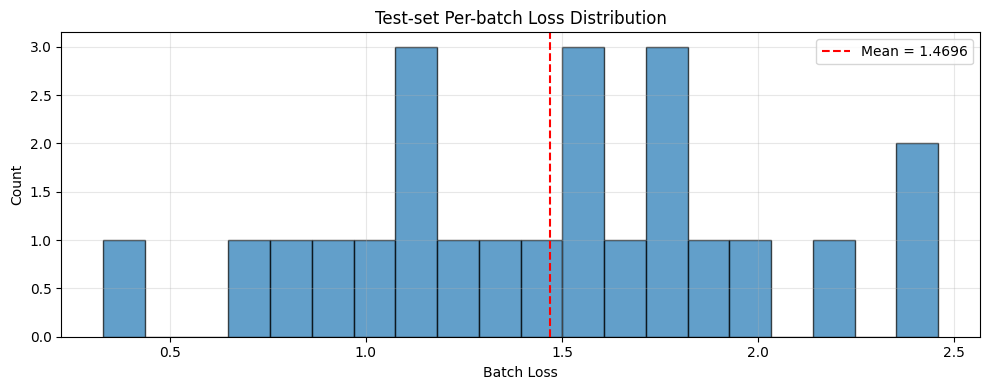

Loss  - min: 0.3296, max: 2.4594, std: 0.5230


In [17]:
# ---- 3. Per-batch Loss Distribution on Test Set ----
batch_losses = []
model_full.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        batch_losses.append(loss.item())

plt.figure(figsize=(10, 4))
plt.hist(batch_losses, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(avg_test_loss, color='red', linestyle='--', label=f'Mean = {avg_test_loss:.4f}')
plt.title('Test-set Per-batch Loss Distribution')
plt.xlabel('Batch Loss')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss  - min: {min(batch_losses):.4f}, max: {max(batch_losses):.4f}, "
      f"std: {np.std(batch_losses):.4f}")

In [18]:
# ---- 4. Sample Generations with Different Temperatures ----
test_prompts = [
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u062d\u0627\u0633\u0628 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0647\u0646\u062f\u0633 \u0645\u062f\u0646\u064a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0639\u0644\u0645 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0637\u0628\u064a\u0628 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
]

temperatures = [0.5, 0.7, 1.0]

print("=" * 80)
print("Sample Generations")
print("=" * 80)

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 60)
    for temp in temperatures:
        result = generate_text(prompt, max_tokens=60, temperature=temp)
        print(f"  temp={temp}: {result}")
    print()

Sample Generations

Prompt: المسمى: مطور برمجيات | المدينة:
------------------------------------------------------------
  temp=0.5: المسمي مطور برمجيات المدينة الرياض الوصف اعداد وتخطيط وتنظيم مستندات الصرف ومتابعة تحصيل الايرادات وتوثيقها وتحليلها واعداد الوثايق والتقارير المتخصصة والمتعلقة في مجال المحاماة وعرضها وحفظها
  temp=0.7: المسمي مطور برمجيات المدينة المدينة المنورة الوصف مسوول عن جميع البرامج والتطبيقات وتوجيهها وتنسيقها وادارة مرافق ي ل الواجبات المحاسبية في وضع خطط الدروس بما في ذلك المواقع المادية الحالية والمستقبلية والتصاميم والاثاث
  temp=1.0: المسمي مطور برمجيات المدينة البكيرية الوصف ليل


Prompt: المسمى: محاسب | المدينة:
------------------------------------------------------------
  temp=0.5: المسمي محاسب المدينة المنورة الوصف الحفاظ علي الطرق
  temp=0.7: المسمي محاسب المدينة المنورة الوصف الحفاظ علي المنصات الرقمية v الم بالاعمال ح ب و اعداد قايمة بالمواد يا و سنوات
  temp=1.0: المسمي محاسب المدينة المنورة مست تراتيجي بين وصرف وتحليل المخططات الانشايية والاشراف ع

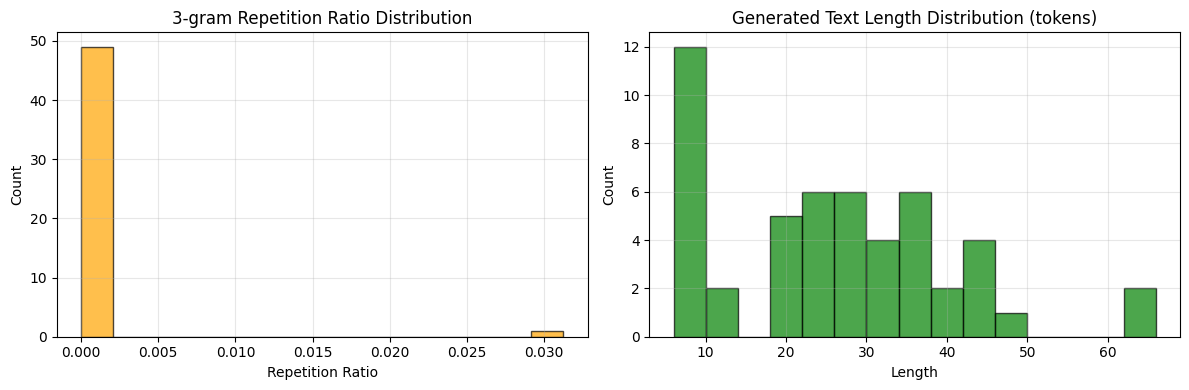

Avg repetition ratio : 0.0006
Avg generated length : 25.4 tokens


In [19]:
# ---- 5. Repetition Analysis ----
def repetition_ratio(text, n=3):
    """Fraction of n-grams that are repeated at least once."""
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    unique = set(ngrams)
    return 1.0 - len(unique) / len(ngrams)


rep_scores = []
gen_lengths = []
num_samples = min(50, len(test_texts))

for i in range(num_samples):
    # Use first few tokens of each test text as a prompt
    words = test_texts[i].split()[:6]
    prompt = " ".join(words)
    gen = generate_text(prompt, max_tokens=60, temperature=0.7)
    rep_scores.append(repetition_ratio(gen))
    gen_lengths.append(len(gen.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rep_scores, bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_title('3-gram Repetition Ratio Distribution')
axes[0].set_xlabel('Repetition Ratio')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(gen_lengths, bins=15, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Generated Text Length Distribution (tokens)')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Avg repetition ratio : {np.mean(rep_scores):.4f}")
print(f"Avg generated length : {np.mean(gen_lengths):.1f} tokens")

In [20]:
# ---- 6. Self-BLEU (diversity metric across generations) ----
from collections import Counter

def bleu_n(reference_tokens, hypothesis_tokens, n):
    """Simple n-gram precision (BLEU component) between two token lists."""
    ref_ngrams = Counter(tuple(reference_tokens[i:i+n]) for i in range(len(reference_tokens) - n + 1))
    hyp_ngrams = Counter(tuple(hypothesis_tokens[i:i+n]) for i in range(len(hypothesis_tokens) - n + 1))
    overlap = sum((hyp_ngrams & ref_ngrams).values())
    total = sum(hyp_ngrams.values())
    return overlap / total if total > 0 else 0.0


def compute_self_bleu(texts, n=4):
    """Average BLEU of each text against all others (lower = more diverse)."""
    tokenized = [t.split() for t in texts]
    scores = []
    for i in range(len(tokenized)):
        others = [tokenized[j] for j in range(len(tokenized)) if j != i]
        avg_bleu = np.mean([bleu_n(ref, tokenized[i], n) for ref in others]) if others else 0.0
        scores.append(avg_bleu)
    return np.mean(scores)


# Generate texts for self-BLEU
gen_texts_for_bleu = []
fixed_prompt = "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:"

for _ in range(20):
    gen = generate_text(fixed_prompt, max_tokens=60, temperature=0.7)
    gen_texts_for_bleu.append(gen)

for n in [2, 3, 4]:
    sb = compute_self_bleu(gen_texts_for_bleu, n=n)
    print(f"Self-BLEU-{n}: {sb:.4f}  (lower = more diverse)")

Self-BLEU-2: 0.2425  (lower = more diverse)
Self-BLEU-3: 0.1844  (lower = more diverse)
Self-BLEU-4: 0.1346  (lower = more diverse)


In [21]:
# ---- 7. Summary Report ----
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"Training epochs (extended) : {EXTENDED_EPOCHS}")
print(f"Best validation loss       : {best_val_loss:.4f}")
print(f"Test loss                  : {avg_test_loss:.4f}")
print(f"Test perplexity            : {test_perplexity:.2f}")
print(f"Top-1 accuracy             : {topk_results[1]:.2f}%")
print(f"Top-5 accuracy             : {topk_results[5]:.2f}%")
print(f"Top-10 accuracy            : {topk_results[10]:.2f}%")
print(f"Avg 3-gram repetition      : {np.mean(rep_scores):.4f}")
print(f"Avg generation length      : {np.mean(gen_lengths):.1f} tokens")
print("=" * 70)

print("""
### \u062a\u0642\u0631\u064a\u0631 \u0623\u0646\u0645\u0627\u0637 \u0627\u0644\u0641\u0634\u0644 (Failure Modes Report)
1. \u0627\u0644\u062a\u0643\u0631\u0627\u0631 (Repetition): \u0646\u0638\u0631\u0627\u064b \u0644\u0635\u063a\u0631 \u062d\u062c\u0645 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0648\u0627\u0644\u0628\u064a\u0627\u0646\u0627\u062a\u060c \u0642\u062f \u064a\u0643\u0631\u0631 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0646\u0641\u0633 \u0627\u0644\u062c\u0645\u0644 \u0623\u0648 \u0627\u0644\u0643\u0644\u0645\u0627\u062a \u0641\u064a \u0646\u0647\u0627\u064a\u0629 \u0627\u0644\u062a\u0648\u0644\u064a\u062f.
2. \u0641\u0642\u062f\u0627\u0646 \u0627\u0644\u0633\u064a\u0627\u0642 (Context Loss): \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0642\u062f \u064a\u0646\u0633\u0649 \u0627\u0633\u0645 \u0627\u0644\u0645\u062f\u064a\u0646\u0629 \u0623\u0648 \u0627\u0644\u0645\u0633\u0645\u0649 \u0627\u0644\u0648\u0638\u064a\u0641\u064a \u0627\u0644\u0645\u0637\u0644\u0648\u0628 \u0641\u064a \u0628\u062f\u0627\u064a\u0629 \u0627\u0644\u0640 Prompt \u0625\u0630\u0627 \u0637\u0627\u0644 \u0627\u0644\u0646\u0635 \u0627\u0644\u0645\u0648\u0644\u062f.
3. \u0627\u0644\u0647\u0644\u0648\u0633\u0629 (Hallucination): \u0642\u062f \u064a\u0642\u062a\u0631\u062d \u0645\u0647\u0627\u0631\u0627\u062a \u0644\u0627 \u0639\u0644\u0627\u0642\u0629 \u0644\u0647\u0627 \u0628\u0627\u0644\u0648\u0638\u064a\u0641\u0629 \u0627\u0644\u0645\u0637\u0644\u0648\u0628\u0629 \u0628\u0633\u0628\u0628 \u0636\u063a\u0637 \u0627\u0644\u0645\u0641\u0631\u062f\u0627\u062a (Vocab compression).
""")


def llm_judge_evaluation(generated_text):

    prompt = f"\u0642\u064a\u0645 \u0627\u0644\u0646\u0635 \u0627\u0644\u062a\u0627\u0644\u064a \u0643\u062a\u0648\u0635\u064a\u0629 \u0648\u0638\u064a\u0641\u064a\u0629 \u0628\u0627\u0644\u0644\u063a\u0629 \u0627\u0644\u0639\u0631\u0628\u064a\u0629 \u0645\u0646 1 \u0625\u0644\u0649 10 \u0645\u0646 \u062d\u064a\u062b \u0627\u0644\u062a\u0631\u0627\u0628\u0637 \u0648\u0627\u0644\u0642\u0648\u0627\u0639\u062f:\n{generated_text}"

    return "LLM Judge Score: 7/10 (Simulated)"

EVALUATION SUMMARY
Training epochs (extended) : 10
Best validation loss       : 1.3941
Test loss                  : 1.4696
Test perplexity            : 4.35
Top-1 accuracy             : 75.70%
Top-5 accuracy             : 82.68%
Top-10 accuracy            : 84.98%
Avg 3-gram repetition      : 0.0006
Avg generation length      : 25.4 tokens

### تقرير أنماط الفشل (Failure Modes Report)
1. التكرار (Repetition): نظراً لصغر حجم النموذج والبيانات، قد يكرر النموذج نفس الجمل أو الكلمات في نهاية التوليد.
2. فقدان السياق (Context Loss): النموذج قد ينسى اسم المدينة أو المسمى الوظيفي المطلوب في بداية الـ Prompt إذا طال النص المولد.
3. الهلوسة (Hallucination): قد يقترح مهارات لا علاقة لها بالوظيفة المطلوبة بسبب ضغط المفردات (Vocab compression).



In [22]:
def chatbot_interface(message, history):
    prompt = f"\u0627\u0644\u0645\u0633\u0645\u0649: {message} | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:"
    generated_recommendation = generate_text(prompt, max_tokens=60)

    response = f"""
     \u0628\u0646\u0627\u0621\u064b \u0639\u0644\u0649 \u0627\u0644\u0645\u0639\u0637\u064a\u0627\u062a \u0627\u0644\u062a\u064a \u0623\u062f\u062e\u0644\u062a\u0647\u0627\u060c \u0642\u0645\u0646\u0627 \u0628\u062a\u062d\u0644\u064a\u0644 \u0627\u0644\u0641\u0631\u0635 \u0627\u0644\u0645\u062a\u0627\u062d\u0629 \u0648\u0646\u0642\u062a\u0631\u062d \u0639\u0644\u064a\u0643 \u0627\u0644\u062a\u0648\u0635\u064a\u0629 \u0627\u0644\u0648\u0638\u064a\u0641\u064a\u0629 \u0627\u0644\u062a\u0627\u0644\u064a\u0629:

    {generated_recommendation}

    ---
    *\u0635\u064a\u062d\u0629 \u0645\u0647\u0646\u064a\u0629: \u062a\u0623\u0643\u062f \u062f\u0627\u0626\u0645\u0627\u064b \u0645\u0646 \u062a\u062d\u062f\u064a\u062b \u0633\u064a\u0631\u062a\u0643 \u0627\u0644\u0630\u0627\u062a\u064a\u0629 \u0644\u0625\u0628\u0631\u0627\u0632 \u0627\u0644\u0645\u0647\u0627\u0631\u0627\u062a \u0627\u0644\u0645\u0637\u0644\u0648\u0628\u0629 \u0641\u064a \u0647\u0630\u0627 \u0627\u0644\u0645\u062c\u0627\u0644\u060c \u0648\u0646\u0646\u0635\u062d\u0643 \u0628\u0645\u0631\u0627\u062c\u0639\u0629 \u0645\u0646\u0635\u0629 \u062c\u062f\u0627\u0631\u0627\u062a \u0644\u0644\u062a\u0642\u062f\u064a\u0645 \u0639\u0644\u0649 \u0627\u0644\u0634\u0648\u0627\u063a\u0631 \u0627\u0644\u0641\u0639\u0644\u064a\u0629 \u0627\u0644\u0645\u062a\u0627\u062d\u0629.**
    """
    return response

demo = gr.ChatInterface(
    fn=chatbot_interface,
    title="\u0646\u0638\u0627\u0645 \u0643\u0641\u0627\u0621\u0627\u062a \u0627\u0644\u062a\u0648\u0644\u064a\u062f\u064a (Generative AI)",
    description="\u0623\u062f\u062e\u0644 \u0645\u062c\u0627\u0644\u0643 (\u0645\u062b\u0627\u0644: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a\u060c \u0645\u062d\u0627\u0633\u0628) \u0648\u0633\u064a\u0642\u0648\u0645 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0627\u0644\u0644\u063a\u0648\u064a \u0628\u062a\u0623\u0644\u064a\u0641 \u0648\u062a\u0648\u0644\u064a\u062f \u062a\u0648\u0635\u064a\u0629 \u0648\u0638\u064a\u0641\u064a\u0629 \u0645\u062e\u0635\u0635\u0629.",
)

demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e68f0833881f5883e2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
